<a href="https://colab.research.google.com/github/reddoma742/DTQEM-v10.1/blob/main/DTQEM%20v10.1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

DTQEM v10.1 – Fully corrected syntax, Liouvillian + expm.

=== BENCHMARKS (DTQEM v10.1) ===
✓ dephasing_error: 8.33e-16
✓ relaxation_error: 7.77e-16
✓ entropy_increase: True


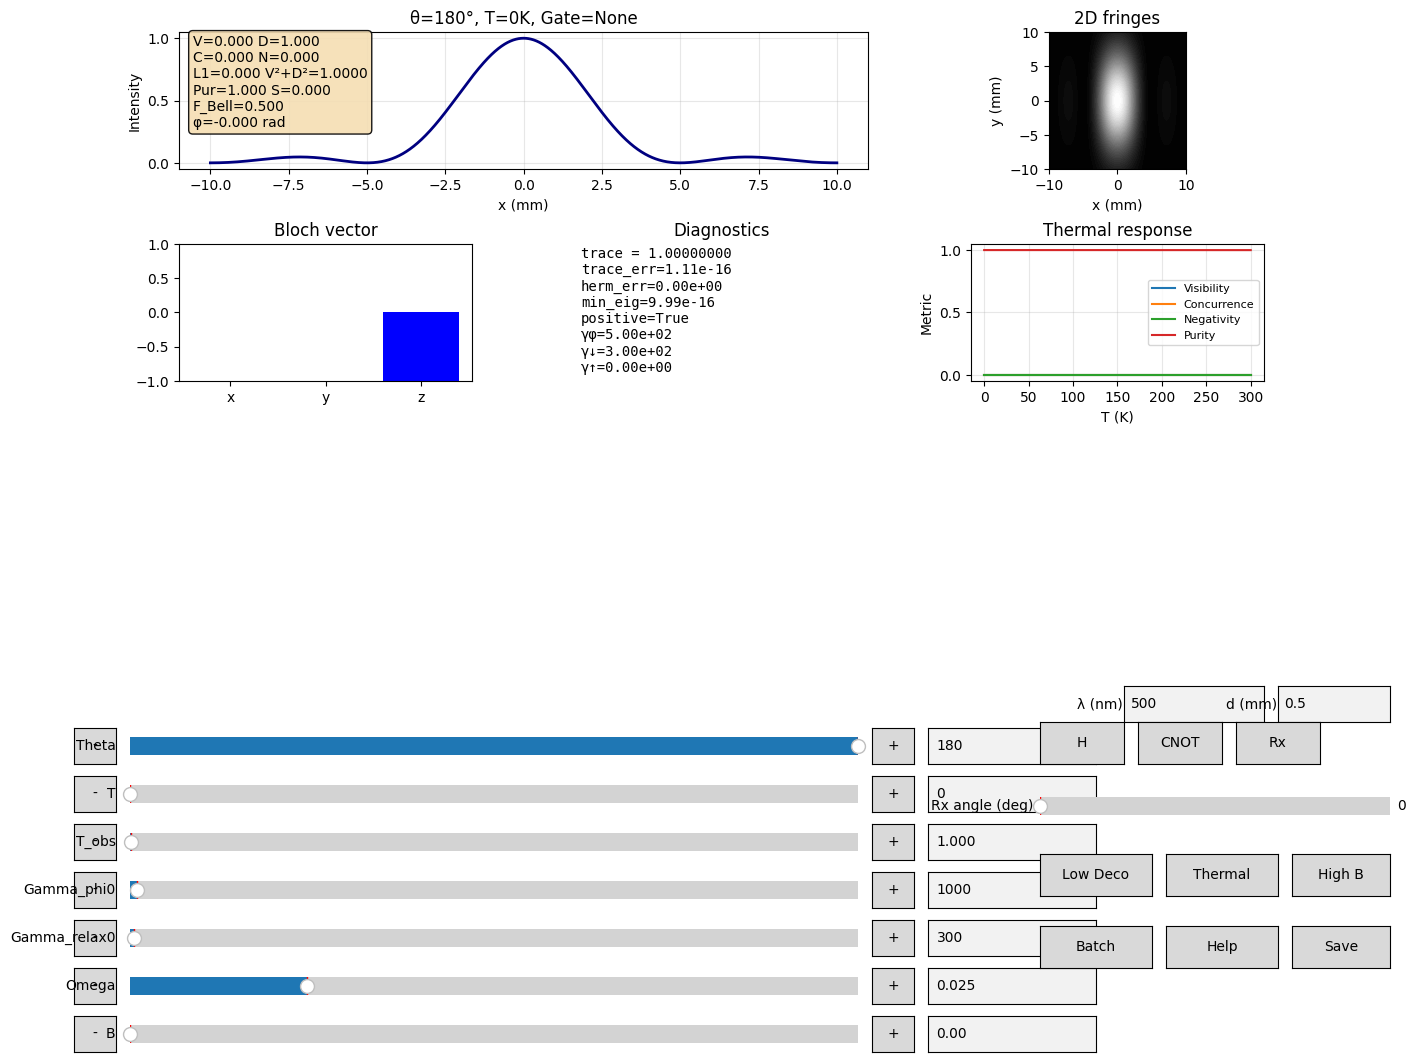

In [1]:

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider, Button, TextBox
from scipy.special import sinc
from scipy.linalg import expm, sqrtm
import csv, json, os

# ----------------------------------------------------------------------
# Constants
# ----------------------------------------------------------------------
class Constants:
    hbar = 1.0545718e-34
    k_B = 1.380649e-23
    eV = 1.60217662e-19
    mu_B = 9.2740100783e-24

I2 = np.eye(2, dtype=complex)
SX = np.array([[0,1],[1,0]], dtype=complex)
SY = np.array([[0,-1j],[1j,0]], dtype=complex)
SZ = np.array([[1,0],[0,-1]], dtype=complex)
SP = np.array([[0,1],[0,0]], dtype=complex)
SM = np.array([[0,0],[1,0]], dtype=complex)
def kron(a,b): return np.kron(a,b)

# ----------------------------------------------------------------------
# QuantumState
# ----------------------------------------------------------------------
class QuantumState:
    @staticmethod
    def entangled_state(theta_deg):
        theta = np.radians(theta_deg)
        c = np.cos(theta/2)
        s = np.sin(theta/2)
        return np.array([c,0,0,s], dtype=complex)

    @staticmethod
    def bell_phi_plus():
        return np.array([1,0,0,1], dtype=complex)/np.sqrt(2)

    @staticmethod
    def density_matrix(state):
        return np.outer(state, state.conj())

    @staticmethod
    def partial_trace_B(rho_AB):
        rho = rho_AB.reshape(2,2,2,2)
        rho_A = np.zeros((2,2), dtype=complex)
        for i in range(2):
            for k in range(2):
                rho_A[i,k] = np.sum([rho[i,j,k,j] for j in range(2)])
        return rho_A

    @staticmethod
    def partial_transpose_B(rho_AB):
        rho = rho_AB.reshape(2,2,2,2)
        return np.transpose(rho,(0,3,2,1)).reshape(4,4)

    @staticmethod
    def l1_coherence(rho):
        mask = ~np.eye(4, dtype=bool)
        total = np.sum(np.abs(rho[mask]))
        return float(np.clip(total/6.0,0,1))

    @staticmethod
    def fringe_visibility(rho):
        return float(np.clip(2.0*np.abs(rho[0,3]),0,1))

    @staticmethod
    def visibility(rho):
        return QuantumState.fringe_visibility(rho)

    @staticmethod
    def distinguishability(rho):
        rho_A = QuantumState.partial_trace_B(rho)
        return float(np.abs(np.real(rho_A[0,0]-rho_A[1,1])))

    @staticmethod
    def concurrence(rho):
        sy_sy = kron(SY,SY)
        rho_tilde = sy_sy @ rho.conj() @ sy_sy
        M = rho @ rho_tilde
        ev = np.linalg.eigvals(M)
        sqrt_ev = np.sqrt(np.maximum(np.real(ev),0))
        sqrt_ev = np.sort(sqrt_ev)[::-1]
        return float(max(0, sqrt_ev[0]-sqrt_ev[1]-sqrt_ev[2]-sqrt_ev[3]))

    @staticmethod
    def negativity(rho):
        rho_pt = QuantumState.partial_transpose_B(rho)
        evals = np.linalg.eigvalsh(0.5*(rho_pt+rho_pt.conj().T))
        return float(np.sum(np.abs(evals[evals<0])))

    @staticmethod
    def fidelity(rho, sigma):
        eps = 1e-12
        rho_reg = (1-eps)*rho + eps*np.eye(4)/4
        sigma_reg = (1-eps)*sigma + eps*np.eye(4)/4
        sqrt_rho = sqrtm(rho_reg)
        middle = sqrt_rho @ sigma_reg @ sqrt_rho
        val = np.trace(sqrtm(middle))
        return float(np.real(val*np.conj(val)))

    @staticmethod
    def purity(rho):
        return float(np.real(np.trace(rho@rho)))

    @staticmethod
    def entropy(rho):
        ev = np.linalg.eigvalsh(0.5*(rho+rho.conj().T))
        ev = np.real(ev)
        ev = ev[ev>1e-15]
        return float(-np.sum(ev*np.log(ev)))

    @staticmethod
    def bloch_vector(rho_A):
        x = np.real(np.trace(rho_A@SX))
        y = np.real(np.trace(rho_A@SY))
        z = np.real(np.trace(rho_A@SZ))
        return float(x), float(y), float(z)

    @staticmethod
    def diagnostics(rho):
        rho_h = 0.5*(rho+rho.conj().T)
        trace = np.trace(rho_h)
        trace_err = float(np.abs(trace-1))
        herm_err = float(np.linalg.norm(rho-rho.conj().T))
        evals = np.linalg.eigvalsh(rho_h)
        min_eval = float(np.min(np.real(evals)))
        positive = min_eval >= -1e-10
        return {
            'trace': float(np.real(trace)),
            'trace_error': trace_err,
            'hermiticity_error': herm_err,
            'min_eigenvalue': min_eval,
            'positive': positive
        }

# ----------------------------------------------------------------------
# LindbladSolver with Liouvillian + expm
# ----------------------------------------------------------------------
class LindbladSolver:
    def __init__(self, g_factor=2.0, omega_eV=0.025):
        self.g_factor = g_factor
        self.omega_eV = omega_eV
        self.B = 0.0
        self.axis = 'z'

    def set_magnetic_field(self, B, axis='z'):
        self.B = B
        self.axis = axis

    def thermal_occupation(self, T):
        if T <= 0:
            return 0.0
        omega = self.omega_eV * Constants.eV / Constants.hbar
        x = Constants.hbar * omega / (Constants.k_B * T)
        if x > 700:
            return 0.0
        return 1.0 / np.expm1(x)

    def hamiltonian(self):
        coeff = 0.5 * self.g_factor * Constants.mu_B * self.B
        sigma = {'x':SX,'y':SY,'z':SZ}[self.axis]
        return coeff * kron(sigma, I2)

    def jump_operators(self, gamma_phi0, gamma_relax0, T):
        n_th = self.thermal_occupation(T)
        g_phi = gamma_phi0 * (2*n_th+1) / 2.0
        g_down = gamma_relax0 * (n_th+1)
        g_up = gamma_relax0 * n_th
        Ls = []
        if g_phi > 0:
            Ls.append(np.sqrt(g_phi) * kron(SZ, I2))
        if g_down > 0:
            Ls.append(np.sqrt(g_down) * kron(SM, I2))
        if g_up > 0:
            Ls.append(np.sqrt(g_up) * kron(SP, I2))
        return Ls, g_phi, g_down, g_up

    def build_liouvillian(self, gamma_phi0, gamma_relax0, T):
        H = self.hamiltonian()
        Ls, _, _, _ = self.jump_operators(gamma_phi0, gamma_relax0, T)
        dim = 4
        size = dim*dim
        L = np.zeros((size,size), dtype=complex)
        L += -1j / Constants.hbar * (np.kron(H, np.eye(dim)) - np.kron(np.eye(dim), H.T))
        for Lj in Ls:
            Lj_dag = Lj.conj().T
            term1 = np.kron(Lj, Lj.conj())
            LjLj = Lj_dag @ Lj
            term2 = -0.5 * (np.kron(LjLj, np.eye(dim)) + np.kron(np.eye(dim), LjLj.T))
            L += term1 + term2
        return L

    def evolve(self, rho0, t_obs, gamma_phi0, gamma_relax0, T):
        L = self.build_liouvillian(gamma_phi0, gamma_relax0, T)
        rho_vec = rho0.flatten('C')
        rho_vec_t = expm(L * t_obs) @ rho_vec
        rho_t = rho_vec_t.reshape(4,4)
        rho_t = 0.5*(rho_t + rho_t.conj().T)
        evals, evecs = np.linalg.eigh(rho_t)
        evals = np.maximum(evals, 1e-15)
        rho_t = evecs @ np.diag(evals) @ evecs.conj().T
        tr = np.trace(rho_t)
        if np.abs(tr) > 1e-15:
            rho_t /= tr
        _, g_phi, g_down, g_up = self.jump_operators(gamma_phi0, gamma_relax0, T)
        return rho_t, {'gamma_phi': g_phi, 'gamma_down': g_down, 'gamma_up': g_up}

# ----------------------------------------------------------------------
# Quantum Gates
# ----------------------------------------------------------------------
class QuantumGateSimulator:
    @staticmethod
    def hadamard():
        return (1/np.sqrt(2))*np.array([[1,1],[1,-1]], dtype=complex)

    @staticmethod
    def cnot():
        return np.array([[1,0,0,0],[0,1,0,0],[0,0,0,1],[0,0,1,0]], dtype=complex)

    @staticmethod
    def rx(theta_deg):
        theta = np.radians(theta_deg)
        return np.array([[np.cos(theta/2), -1j*np.sin(theta/2)], [-1j*np.sin(theta/2), np.cos(theta/2)]], dtype=complex)

    @staticmethod
    def apply_gate(rho, gate):
        if gate.shape == (2,2):
            full_gate = kron(gate, I2)
        else:
            full_gate = gate
        rho_new = full_gate @ rho @ full_gate.conj().T
        tr = np.trace(rho_new)
        if np.abs(tr) > 1e-15:
            rho_new /= tr
        return rho_new

# ----------------------------------------------------------------------
# Main DTQEM v10.1 model
# ----------------------------------------------------------------------
class DTQEM_v10:
    def __init__(self, t_obs=1e-6, gamma_phi0=1000.0, gamma_relax0=300.0, omega_eV=0.025):
        self.t_obs = t_obs
        self.gamma_phi0 = gamma_phi0
        self.gamma_relax0 = gamma_relax0
        self.omega_eV = omega_eV
        self.solver = LindbladSolver(omega_eV=omega_eV)
        self.last_rates = {}

    def set_magnetic_field(self, B, axis='z'):
        self.solver.set_magnetic_field(B, axis)

    def final_state(self, theta_deg, T, gate=None, gate_params=None):
        psi = QuantumState.entangled_state(theta_deg)
        rho0 = QuantumState.density_matrix(psi)
        rho, rates = self.solver.evolve(rho0, self.t_obs, self.gamma_phi0, self.gamma_relax0, T)
        self.last_rates = rates
        if gate is not None:
            if gate == 'H':
                U = QuantumGateSimulator.hadamard()
            elif gate == 'CNOT':
                U = QuantumGateSimulator.cnot()
            elif gate == 'Rx' and gate_params is not None:
                angle = gate_params.get('angle_deg', 0)
                U = QuantumGateSimulator.rx(angle)
            else:
                U = None
            if U is not None:
                rho = QuantumGateSimulator.apply_gate(rho, U)
        return rho

    def phase_shift(self):
        H = self.solver.hamiltonian()
        ev = np.linalg.eigvalsh(H)
        if len(ev) >= 2:
            return float((ev[-1]-ev[0])*self.t_obs/Constants.hbar)
        return 0.0

# ----------------------------------------------------------------------
# DoubleSlit
# ----------------------------------------------------------------------
class DoubleSlit:
    def __init__(self, lam=500e-9, d=0.5e-3, L=1.0, a_slit=0.1e-3):
        self.lam = lam
        self.d = d
        self.L = L
        self.a = a_slit

    def intensity(self, x, V, phi_shift=0.0):
        delta = 2*np.pi*self.d*x/(self.lam*self.L)
        beta = np.pi*self.a*x/(self.lam*self.L)
        envelope = sinc(beta/np.pi)**2
        I = envelope * (1 + np.clip(V,0,1)*np.cos(delta+phi_shift))
        if np.max(I)>0:
            I /= np.max(I)
        return I

    def pattern_1d(self, V, phi_shift=0.0, x_range=(-0.01,0.01), points=2000):
        x = np.linspace(x_range[0], x_range[1], points)
        return x, self.intensity(x, V, phi_shift)

    def pattern_2d(self, V, phi_shift=0.0, xy_range=(-0.01,0.01), res=250):
        x = np.linspace(xy_range[0], xy_range[1], res)
        y = np.linspace(xy_range[0], xy_range[1], res)
        X,Y = np.meshgrid(x,y)
        I_line = self.intensity(x, V, phi_shift)
        envelope_y = np.exp(-(Y/(0.35*(xy_range[1]-xy_range[0])))**2)
        I = np.tile(I_line, (res,1)) * envelope_y
        if np.max(I)>0:
            I /= np.max(I)
        return X,Y,I

# ----------------------------------------------------------------------
# Benchmarks
# ----------------------------------------------------------------------
def run_benchmarks(gamma_phi0=500.0, gamma_relax0=2000.0, omega_eV=0.025):
    solver = LindbladSolver(omega_eV=omega_eV)
    solver.set_magnetic_field(0.0)
    t_obs = 0.0005

    # Pure dephasing
    psi = np.array([1,0,1,0], dtype=np.complex128)/np.sqrt(2)
    rho0 = QuantumState.density_matrix(psi)
    analytical = 0.5 * np.exp(-gamma_phi0 * t_obs)
    rho_t, _ = solver.evolve(rho0, t_obs, gamma_phi0, 0.0, 0.0)
    numerical = np.abs(rho_t[0,2])
    deph_err = float(abs(numerical - analytical))

    # Relaxation at T=0
    psi1 = np.array([0,1,0,0], dtype=np.complex128)
    rho1 = QuantumState.density_matrix(psi1)
    rho_rel, _ = solver.evolve(rho1, t_obs, 0.0, gamma_relax0, 0.0)
    analytical_rel = np.exp(-gamma_relax0 * t_obs)
    numerical_rel = np.real(rho_rel[1,1])
    rel_err = float(abs(numerical_rel - analytical_rel))

    # Entropy increase
    psi0 = np.array([1,0,0,0], dtype=np.complex128)
    rho_init = QuantumState.density_matrix(psi0)
    S0 = QuantumState.entropy(rho_init)
    t_long = 2.0
    rho_final, _ = solver.evolve(rho_init, t_long, gamma_phi0, gamma_relax0, 100.0)
    S1 = QuantumState.entropy(rho_final)
    purity_final = QuantumState.purity(rho_final)
    entropy_inc = (S1 - S0) > 1e-6 and purity_final < 0.99

    results = {'dephasing_error': deph_err, 'relaxation_error': rel_err, 'entropy_increase': entropy_inc}
    print("\n=== BENCHMARKS (DTQEM v10.1) ===")
    for key,val in results.items():
        if key == 'entropy_increase':
            print(f"{'✓' if val else '✗'} {key}: {val}")
        else:
            status = '✓' if val < 1e-12 else ('⚠️' if val < 1e-6 else '❌')
            print(f"{status} {key}: {val:.2e}")
    return results

# ----------------------------------------------------------------------
# GUI
# ----------------------------------------------------------------------
class GUI:
    def __init__(self, out_dir='dtqem_outputs_v10'):
        self.out_dir = out_dir
        os.makedirs(out_dir, exist_ok=True)
        self.model = DTQEM_v10()
        self.ds = DoubleSlit()
        self.fig = None
        self.axes = {}
        self.sliders = {}
        self.textboxes = {}
        self.current_params = {
            'theta': 180, 'T': 0, 't_obs': 1.0,
            'gamma_phi0': 1000, 'gamma_relax0': 300,
            'omega': 0.025, 'B': 0.0,
            'lam': 500, 'd': 0.5,
            'gate': 'None', 'rx_angle': 0.0
        }
        self.presets = {
            'low_decoherence': {
                'theta': 180, 'T': 0, 't_obs': 1.0,
                'gamma_phi0': 200, 'gamma_relax0': 50,
                'omega': 0.025, 'B': 0.2, 'lam': 500, 'd': 0.5,
                'gate': 'None', 'rx_angle': 0
            },
            'thermal_regime': {
                'theta': 150, 'T': 200, 't_obs': 10.0,
                'gamma_phi0': 2000, 'gamma_relax0': 500,
                'omega': 0.025, 'B': 0.5, 'lam': 500, 'd': 0.5,
                'gate': 'None', 'rx_angle': 0
            },
            'high_field': {
                'theta': 180, 'T': 50, 't_obs': 5.0,
                'gamma_phi0': 800, 'gamma_relax0': 300,
                'omega': 0.025, 'B': 5.0, 'lam': 500, 'd': 0.5,
                'gate': 'None', 'rx_angle': 0
            }
        }

    def set_param(self, key, value):
        if key in self.sliders:
            sld = self.sliders[key]
            value = min(max(value, sld.valmin), sld.valmax)
            sld.set_val(value)
        elif key == 'lam':
            self.ds.lam = float(value) * 1e-9
            self.update(None)
        elif key == 'd':
            self.ds.d = float(value) * 1e-3
            self.update(None)
        elif key == 'gate':
            self.current_params['gate'] = value
            self.update(None)
        elif key == 'rx_angle':
            self.current_params['rx_angle'] = value
            self.update(None)

    def apply_preset(self, name):
        for k, v in self.presets[name].items():
            self.set_param(k, v)

    def add_slider_row(self, key, label, y, vmin, vmax, vinit, vstep, fmt='{:.3f}'):
        ax_minus = plt.axes([0.05, y, 0.03, 0.03])
        ax_slider = plt.axes([0.09, y, 0.52, 0.03])
        ax_plus = plt.axes([0.62, y, 0.03, 0.03])
        ax_box = plt.axes([0.66, y, 0.12, 0.03])

        btn_minus = Button(ax_minus, '-')
        sld = Slider(ax_slider, label, vmin, vmax, valinit=vinit, valstep=vstep)
        btn_plus = Button(ax_plus, '+')
        tb = TextBox(ax_box, '', initial=fmt.format(vinit))

        def on_minus(event):
            self.set_param(key, sld.val - vstep)
        def on_plus(event):
            self.set_param(key, sld.val + vstep)
        def on_submit(text):
            try:
                self.set_param(key, float(text))
            except:
                pass

        btn_minus.on_clicked(on_minus)
        btn_plus.on_clicked(on_plus)
        sld.on_changed(self.update)
        sld.on_changed(lambda val: tb.set_val(fmt.format(val)))
        tb.on_submit(on_submit)

        self.sliders[key] = sld
        self.textboxes[key] = tb

    def batch_run(self, event):
        theta_range = np.linspace(0,180,50)
        T_range = np.linspace(0,300,50)
        V_surf = np.zeros((len(T_range), len(theta_range)))
        gate = self.current_params.get('gate', None)
        rx_angle = self.current_params.get('rx_angle', 0.0)
        for i, Tk in enumerate(T_range):
            for j, th in enumerate(theta_range):
                rho = self.model.final_state(th, Tk,
                    gate=gate if gate!='None' else None,
                    gate_params={'angle_deg': rx_angle} if gate=='Rx' else None)
                V_surf[i,j] = QuantumState.fringe_visibility(rho)
        plt.figure(figsize=(10,6))
        plt.contourf(theta_range, T_range, V_surf, levels=50, cmap='viridis')
        plt.colorbar(label='Visibility')
        plt.xlabel('θ (deg)')
        plt.ylabel('T (K)')
        plt.title('Batch visibility map')
        plt.savefig(os.path.join(self.out_dir, 'batch_map.png'), dpi=150)
        plt.close()
        print(f"Saved batch map to {self.out_dir}")

    def show_help(self, event):
        help_text = (
            "=== DTQEM v10.1 METRICS ===\n"
            "V: visibility (coherence)\n"
            "D: distinguishability\n"
            "C: concurrence\n"
            "N: negativity\n"
            "Pur: purity\n"
            "S: entropy\n"
            "F_Bell: fidelity to Bell state\n"
            "γφ,γ↓,γ↑: decoherence rates\n"
            "Gates: H, CNOT, Rx"
        )
        plt.figure(figsize=(6,8))
        plt.text(0.05, 0.95, help_text, va='top', fontsize=10, family='monospace')
        plt.axis('off')
        plt.title('Help')
        plt.show()

    def update(self, _):
        theta = self.sliders['theta'].val
        T = self.sliders['T'].val
        t_obs_us = self.sliders['t_obs'].val
        g_phi0 = self.sliders['gamma_phi0'].val
        g_rel0 = self.sliders['gamma_relax0'].val
        omega = self.sliders['omega'].val
        B = self.sliders['B'].val
        lam_nm = self.sliders['lam'].val
        d_mm = self.sliders['d'].val
        gate = self.current_params.get('gate', 'None')
        rx_angle = self.current_params.get('rx_angle', 0.0)

        self.model.t_obs = t_obs_us * 1e-6
        self.model.gamma_phi0 = g_phi0
        self.model.gamma_relax0 = g_rel0
        self.model.omega_eV = omega
        self.model.set_magnetic_field(B)
        self.ds.lam = lam_nm * 1e-9
        self.ds.d = d_mm * 1e-3

        rho = self.model.final_state(theta, T,
            gate=gate if gate!='None' else None,
            gate_params={'angle_deg': rx_angle} if gate=='Rx' else None)

        V = QuantumState.fringe_visibility(rho)
        l1c = QuantumState.l1_coherence(rho)
        D = QuantumState.distinguishability(rho)
        C = QuantumState.concurrence(rho)
        N = QuantumState.negativity(rho)
        comp = V*V + D*D
        rhoA = QuantumState.partial_trace_B(rho)
        xb, yb, zb = QuantumState.bloch_vector(rhoA)
        pur = QuantumState.purity(rho)
        ent = QuantumState.entropy(rho)
        bell_rho = QuantumState.density_matrix(QuantumState.bell_phi_plus())
        F_bell = QuantumState.fidelity(rho, bell_rho)
        phi_shift = self.model.phase_shift()
        rates = self.model.last_rates
        diag = QuantumState.diagnostics(rho)

        ax = self.axes['int']
        ax.clear()
        x, I = self.ds.pattern_1d(V, phi_shift)
        ax.plot(x*1e3, I, 'navy', lw=2)
        ax.set_title(f'θ={theta:.0f}°, T={T:.0f}K, Gate={gate}')
        ax.set_xlabel('x (mm)')
        ax.set_ylabel('Intensity')
        ax.grid(alpha=0.3)
        info = (f'V={V:.3f} D={D:.3f}\n'
                f'C={C:.3f} N={N:.3f}\n'
                f'L1={l1c:.3f} V²+D²={comp:.4f}\n'
                f'Pur={pur:.3f} S={ent:.3f}\n'
                f'F_Bell={F_bell:.3f}\n'
                f'φ={phi_shift:.3f} rad')
        ax.text(0.02, 0.98, info, transform=ax.transAxes, va='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.9))

        ax = self.axes['2d']
        ax.clear()
        X, Y, I2 = self.ds.pattern_2d(V, phi_shift)
        ax.contourf(X*1e3, Y*1e3, I2, levels=50, cmap='gray')
        ax.set_title('2D fringes')
        ax.set_xlabel('x (mm)')
        ax.set_ylabel('y (mm)')
        ax.set_aspect('equal')

        ax = self.axes['bloch']
        ax.clear()
        ax.bar(['x','y','z'], [xb, yb, zb], color=['r','g','b'])
        ax.set_ylim(-1,1)
        ax.set_title('Bloch vector')

        ax = self.axes['diag']
        ax.clear()
        ax.axis('off')
        diag_text = (f"trace = {diag['trace']:.8f}\n"
                     f"trace_err={diag['trace_error']:.2e}\n"
                     f"herm_err={diag['hermiticity_error']:.2e}\n"
                     f"min_eig={diag['min_eigenvalue']:.2e}\n"
                     f"positive={diag['positive']}\n"
                     f"γφ={rates.get('gamma_phi',0):.2e}\n"
                     f"γ↓={rates.get('gamma_down',0):.2e}\n"
                     f"γ↑={rates.get('gamma_up',0):.2e}")
        ax.text(0.02, 0.98, diag_text, va='top', family='monospace', transform=ax.transAxes)
        ax.set_title('Diagnostics')

        ax = self.axes['therm']
        ax.clear()
        T_range = np.linspace(0,300,50)
        V_curve = []
        C_curve = []
        N_curve = []
        P_curve = []
        for Tk in T_range:
            rhok = self.model.final_state(theta, Tk,
                gate=gate if gate!='None' else None,
                gate_params={'angle_deg': rx_angle} if gate=='Rx' else None)
            V_curve.append(QuantumState.fringe_visibility(rhok))
            C_curve.append(QuantumState.concurrence(rhok))
            N_curve.append(QuantumState.negativity(rhok))
            P_curve.append(QuantumState.purity(rhok))
        ax.plot(T_range, V_curve, label='Visibility')
        ax.plot(T_range, C_curve, label='Concurrence')
        ax.plot(T_range, N_curve, label='Negativity')
        ax.plot(T_range, P_curve, label='Purity')
        ax.set_xlabel('T (K)')
        ax.set_ylabel('Metric')
        ax.grid(alpha=0.3)
        ax.legend(fontsize=8)
        ax.set_title('Thermal response')

        self.fig.canvas.draw_idle()

    def export_batch(self):
        angles = [0,90,120,150,180]
        temps = [0,77,150,300]
        csv_path = os.path.join(self.out_dir, 'results.csv')
        with open(csv_path, 'w', newline='') as f:
            w = csv.writer(f)
            w.writerow(['theta','T','vis','l1','D','conc','neg','pur','ent','fid'])
            bell_rho = QuantumState.density_matrix(QuantumState.bell_phi_plus())
            gate = self.current_params.get('gate', 'None')
            rx = self.current_params.get('rx_angle', 0)
            for th in angles:
                for Tk in temps:
                    rho = self.model.final_state(th, Tk,
                        gate=gate if gate!='None' else None,
                        gate_params={'angle_deg': rx} if gate=='Rx' else None)
                    row = [th, Tk,
                           QuantumState.fringe_visibility(rho),
                           QuantumState.l1_coherence(rho),
                           QuantumState.distinguishability(rho),
                           QuantumState.concurrence(rho),
                           QuantumState.negativity(rho),
                           QuantumState.purity(rho),
                           QuantumState.entropy(rho),
                           QuantumState.fidelity(rho, bell_rho)]
                    w.writerow(row)
        bench = run_benchmarks(self.sliders['gamma_phi0'].val,
                               self.sliders['gamma_relax0'].val,
                               self.sliders['omega'].val)
        with open(os.path.join(self.out_dir, 'benchmark.json'), 'w') as f:
            json.dump({'benchmarks': {k: str(v) for k,v in bench.items()}}, f, indent=2)
        print(f"Saved to {self.out_dir}")

    def save(self, _):
        self.fig.savefig(os.path.join(self.out_dir, 'interactive.png'), dpi=160)
        self.export_batch()
        print(f"Saved all to {self.out_dir}")

    def run(self):
        self.fig = plt.figure(figsize=(14,12))
        gs = self.fig.add_gridspec(3, 3, height_ratios=[1.1,1.1,1.8], hspace=0.45, wspace=0.35)
        self.axes['int'] = self.fig.add_subplot(gs[0,0:2])
        self.axes['2d'] = self.fig.add_subplot(gs[0,2])
        self.axes['bloch'] = self.fig.add_subplot(gs[1,0])
        self.axes['diag'] = self.fig.add_subplot(gs[1,1])
        self.axes['therm'] = self.fig.add_subplot(gs[1,2])
        self.fig.subplots_adjust(bottom=0.34)

        y_pos = [0.27, 0.23, 0.19, 0.15, 0.11, 0.07, 0.03]
        fmt_spec = [
            ('theta', 0, 180, 180, 1, '{:.0f}'),
            ('T', 0, 300, 0, 1, '{:.0f}'),
            ('t_obs', 0.1, 1000, 1, 0.1, '{:.3f}'),
            ('gamma_phi0', 10, 1e5, 1000, 10, '{:.0f}'),
            ('gamma_relax0', 0, 5e4, 300, 10, '{:.0f}'),
            ('omega', 0.001, 0.1, 0.025, 0.001, '{:.3f}'),
            ('B', 0, 10, 0, 0.1, '{:.2f}')
        ]
        for idx, (key, vmin, vmax, vinit, vstep, fmt) in enumerate(fmt_spec):
            self.add_slider_row(key, key.capitalize(), y_pos[idx], vmin, vmax, vinit, vstep, fmt)

        ax_lam = plt.axes([0.80, 0.305, 0.10, 0.03])
        ax_d = plt.axes([0.91, 0.305, 0.08, 0.03])
        tb_lam = TextBox(ax_lam, 'λ (nm)', initial='500')
        tb_d = TextBox(ax_d, 'd (mm)', initial='0.5')
        self.textboxes['lam'] = tb_lam
        self.textboxes['d'] = tb_d

        def lam_submit(t):
            self.ds.lam = float(t) * 1e-9
            self.update(None)
        def d_submit(t):
            self.ds.d = float(t) * 1e-3
            self.update(None)
        tb_lam.on_submit(lam_submit)
        tb_d.on_submit(d_submit)

        from types import SimpleNamespace
        self.sliders['lam'] = SimpleNamespace(val=500, set_val=lambda v: self.set_param('lam', v))
        self.sliders['d'] = SimpleNamespace(val=0.5, set_val=lambda v: self.set_param('d', v))

        # Buttons
        ax_gate_h = plt.axes([0.74, 0.27, 0.06, 0.035])
        ax_gate_cnot = plt.axes([0.81, 0.27, 0.06, 0.035])
        ax_gate_rx = plt.axes([0.88, 0.27, 0.06, 0.035])
        btn_h = Button(ax_gate_h, 'H')
        btn_cnot = Button(ax_gate_cnot, 'CNOT')
        btn_rx = Button(ax_gate_rx, 'Rx')
        btn_h.on_clicked(lambda e: self.set_param('gate', 'H'))
        btn_cnot.on_clicked(lambda e: self.set_param('gate', 'CNOT'))
        btn_rx.on_clicked(lambda e: self.set_param('gate', 'Rx'))

        ax_rx_angle = plt.axes([0.74, 0.22, 0.25, 0.03])
        self.slider_rx = Slider(ax_rx_angle, 'Rx angle (deg)', 0, 360, valinit=0, valstep=10)
        self.slider_rx.on_changed(lambda val: self.set_param('rx_angle', val))

        ax_p1 = plt.axes([0.74, 0.16, 0.08, 0.035])
        ax_p2 = plt.axes([0.83, 0.16, 0.08, 0.035])
        ax_p3 = plt.axes([0.92, 0.16, 0.07, 0.035])
        btn_p1 = Button(ax_p1, 'Low Deco')
        btn_p2 = Button(ax_p2, 'Thermal')
        btn_p3 = Button(ax_p3, 'High B')
        btn_p1.on_clicked(lambda e: self.apply_preset('low_decoherence'))
        btn_p2.on_clicked(lambda e: self.apply_preset('thermal_regime'))
        btn_p3.on_clicked(lambda e: self.apply_preset('high_field'))

        ax_batch = plt.axes([0.74, 0.10, 0.08, 0.035])
        ax_help = plt.axes([0.83, 0.10, 0.08, 0.035])
        ax_save = plt.axes([0.92, 0.10, 0.07, 0.035])
        btn_batch = Button(ax_batch, 'Batch')
        btn_help = Button(ax_help, 'Help')
        btn_save = Button(ax_save, 'Save')
        btn_batch.on_clicked(self.batch_run)
        btn_help.on_clicked(self.show_help)
        btn_save.on_clicked(self.save)

        self.update(None)
        plt.show()

# ----------------------------------------------------------------------
# Main
# ----------------------------------------------------------------------
if __name__ == '__main__':
    print("DTQEM v10.1 – Fully corrected syntax, Liouvillian + expm.")
    run_benchmarks()
    gui = GUI()
    gui.run()